In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
df= pd.read_csv('/kaggle/input/snappfood-persian-sentiment-analysis/Snappfood - Sentiment Analysis.csv',encoding='utf-8', sep='\t+', on_bad_lines='skip', engine='python')


In [3]:
df = df.head(45000)
df = df[['comment', 'label']]
df = df.dropna()

In [4]:
!pip install hazm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 892.6/892.6 kB 19.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 90.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 91.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.7 MB/s eta 0:00:00
  Created wheel for flashtext: filename=flashtext-2.7-py2.py3-none-any.whl size=9297 sha256=854d34d9abf48e83609b416b736d2f14508eedca011bede657156f6950c79107
  Stored in directory: /root/.cache/pip/wheels/bc/be/39/c37ad168eb2ff644c9685f52554440372129450f0b8ed203dd
Successfully built flashtext
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: nltk
    Found existing installation: nltk 3.2.4
    Uninstalling nltk-3.2.4:


In [5]:
from hazm import Normalizer

# نرمال‌سازی متن‌ها
normalizer = Normalizer()

def preprocess_text(text):
    # حذف فاصله‌های اضافی، تبدیل اعداد انگلیسی به فارسی، و نرمال‌سازی متن
    return normalizer.normalize(text)

# اعمال پیش‌پردازش روی ستون 'comment'
df['comment'] = df['comment'].apply(preprocess_text)

# بررسی نتیجه
print(df.head())

# ذخیره دیتاست پیش‌پردازش شده
# data.to_csv("Snappfood-Sentiment Analysis_preprocessed.csv", index=False)
# print("پیش‌پردازش انجام شد و دیتاست ذخیره گردید.")

                                             comment  label
0    واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح    SAD
1  قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...  HAPPY
2  قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط...    SAD
3  عالی بود همه چه درست و به اندازه و کیفیت خوب، ...  HAPPY
4                      شیرینی وانیلی فقط یک مدل بود.  HAPPY


In [6]:
def load_data(file_path, stop_words, encoding='utf-8', sep='\t+', on_bad_lines='skip', engine='python'):
    df = pd.read_csv(file_path, encoding=encoding, sep=sep, on_bad_lines=on_bad_lines, engine=engine)
    # ادامه پردازش داده‌ها...
    return df


In [7]:
# مثال کلمات توقف
stop_words = ["و", "به", "از", "که", "در", "چرا", "هم", "چه", "یا", "با", "تا", "نیز", "را", "پس", "چون", "ولی", "چه", "اگر", "اما", "زیرا", "بس", "ازبس"]

file_path = '/kaggle/input/snappfood-persian-sentiment-analysis/Snappfood - Sentiment Analysis.csv'  # مسیر جدید داده‌ها
data = load_data(file_path, stop_words=stop_words, encoding='utf-8', sep='\t+', on_bad_lines='skip', engine='python')


In [8]:
def preprocess_data(data, stop_words):
    def remove_stop_words(comment):
        return ' '.join([word for word in text.split() if word not in stop_words])

    data['comment'] = data['comment'].apply(remove_stop_words)
    return data


In [9]:
def map_labels(label):
    if label == "HAPPY":
        return 1
    else:
        return 0


df['label'] = df['label'].apply(map_labels)

In [10]:
print(df['label'].value_counts())

label
1    15006
0    14994
Name: count, dtype: int64


In [11]:
df['comment_length'] = df['comment'].apply(len)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


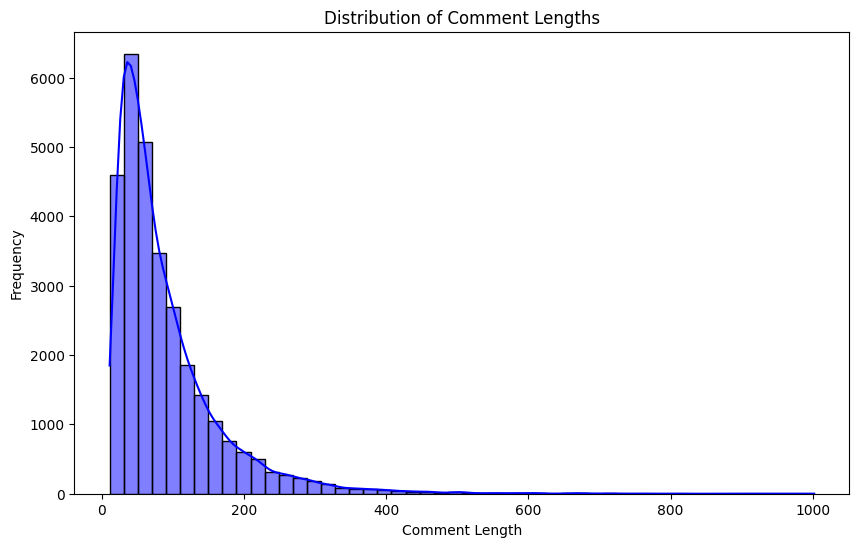

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['comment_length'], bins=50, kde=True, color='blue')
plt.title('Distribution of Comment Lengths')
plt.xlabel('Comment Length')
plt.ylabel('Frequency')
plt.show()

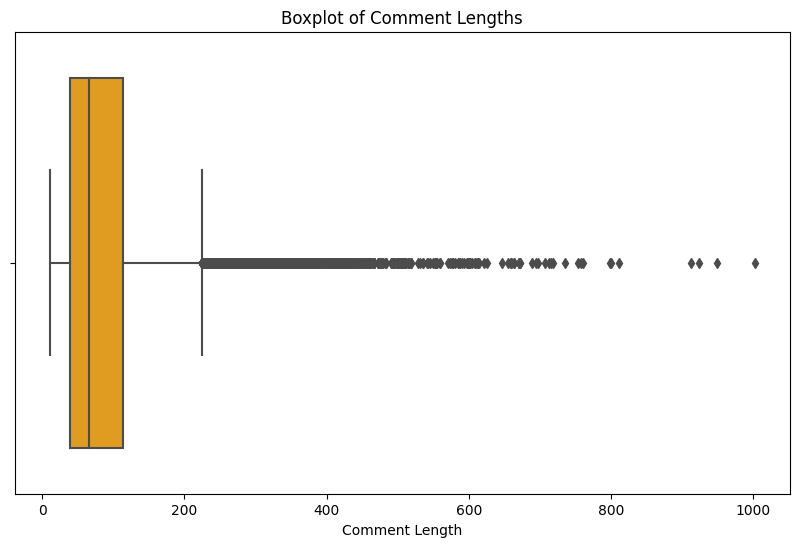

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['comment_length'], color='orange')
plt.title('Boxplot of Comment Lengths')
plt.xlabel('Comment Length')
plt.show()

In [14]:
# محاسبه چارک‌ها  IQR

Q1 = df['comment_length'].quantile(0.25)
Q3 = df['comment_length'].quantile(0.75)
IQR = Q3 - Q1

# تعیین حدود
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Upper limit: {lower_bound}")
print(f"Lower limit: {upper_bound}")

# حذف داده‌های پرت
cleaned_df = df[(df['comment_length'] >= lower_bound) & (df['comment_length'] <= upper_bound)]
print(f"تعداد داده‌های باقی‌مانده: {cleaned_df.shape[0]}")

Upper limit: -72.0
Lower limit: 224.0
تعداد داده‌های باقی‌مانده: 28262


In [15]:
# شمارش داده‌هایی که طول متن آن‌ها بیشتر از 224 است
greater_than_224 = df[df['comment_length'] > 224].shape[0]

# شمارش داده‌هایی که طول متن آن‌ها بین 0 تا 224 است
between_0_and_224 = df[(df['comment_length'] > 0) & (df['comment_length'] <= 224)].shape[0]

print(f"تعداد داده‌هایی که طول متن آن‌ها بیشتر از 224 است: {greater_than_224}")
print(f"تعداد داده‌هایی که طول متن آن‌ها بین 0 تا 224 است: {between_0_and_224}")

تعداد داده‌هایی که طول متن آن‌ها بیشتر از 224 است: 1738
تعداد داده‌هایی که طول متن آن‌ها بین 0 تا 224 است: 28262


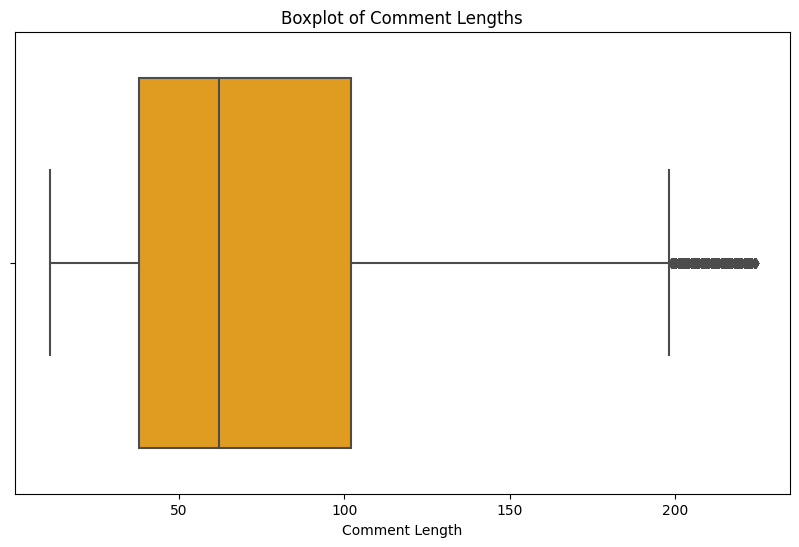

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=cleaned_df['comment_length'], color='orange')
plt.title('Boxplot of Comment Lengths')
plt.xlabel('Comment Length')
plt.show()

In [17]:
# محاسبه چارک‌ها و IQR
Q1 = cleaned_df['comment_length'].quantile(0.25)
Q3 = cleaned_df['comment_length'].quantile(0.75)
IQR = Q3 - Q1

# تعیین حدود
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Upper limit: {lower_bound}")
print(f"Lower limit: {upper_bound}")

# حذف داده‌های پرت
cleaned_df = cleaned_df[(cleaned_df['comment_length'] >= lower_bound) & (cleaned_df['comment_length'] <= upper_bound)]
print(f"تعداد داده‌های باقی‌مانده: {cleaned_df.shape[0]}")

Upper limit: -58.0
Lower limit: 198.0
تعداد داده‌های باقی‌مانده: 27563


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


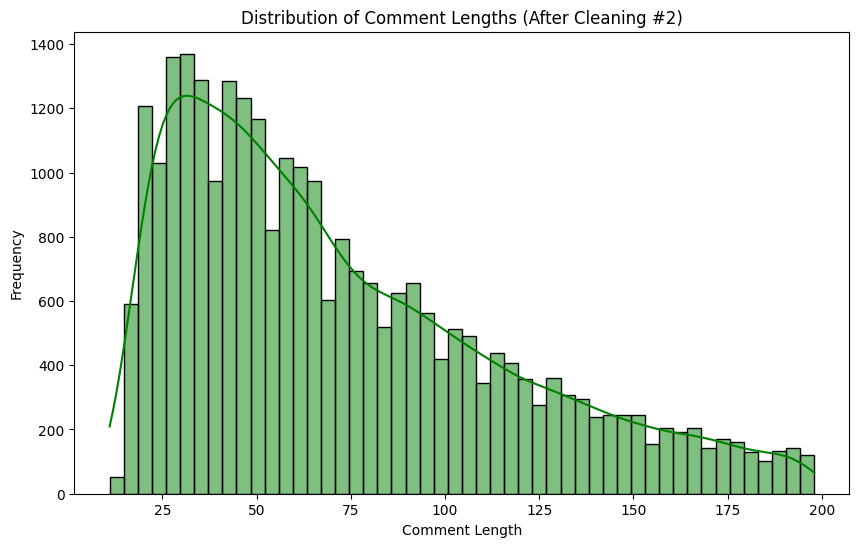

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(cleaned_df['comment_length'], bins=50, kde=True, color='green')
plt.title('Distribution of Comment Lengths (After Cleaning #2)')
plt.xlabel('Comment Length')
plt.ylabel('Frequency')
plt.show()

In [19]:
# حذف ردیف‌هایی که داده‌های خالی دارند
cleaned_df = cleaned_df.dropna()

# حذف ستون‌هایی که داده‌های خالی زیادی دارند
cleaned_df = cleaned_df.dropna(axis=1)

In [20]:
# شمارش داده‌های تکراری
print(f"تعداد داده‌های تکراری: {cleaned_df.duplicated().sum()}")

# حذف داده‌های تکراری
cleaned_df = cleaned_df.drop_duplicates()

تعداد داده‌های تکراری: 11


#### Number of duplicate data's removed: 11

In [21]:
import re

def clean_comment(comment):
    comment = re.sub(r'\s+', ' ', comment)  # حذف فاصله‌های اضافی
    comment = re.sub(r'http\S+', '', comment)  # حذف لینک‌ها
    comment = re.sub(r'[^\w\s]', '', comment)  # حذف کاراکترهای خاص
    comment = re.sub(r'\d+', '', comment)  # حذف اعداد
    return comment.strip()

cleaned_df['comment_cleaned'] = cleaned_df['comment'].apply(clean_comment)

In [22]:
output_path = '/kaggle/working/cleaned_data.csv'  # مسیر ذخیره‌سازی فایل
cleaned_df.to_csv(output_path, index=False, encoding='utf-8')

In [23]:
print(cleaned_df.head())
print(cleaned_df.columns)

                                             comment  label  comment_length  \
0    واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح      0              47   
1  قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...      1             132   
2  قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط...      0              89   
3  عالی بود همه چه درست و به اندازه و کیفیت خوب، ...      1              99   
4                      شیرینی وانیلی فقط یک مدل بود.      1              29   

                                     comment_cleaned  
0    واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح  
1  قرار بود  ساعته برسه ولی نیم ساعت زودتر از موق...  
2  قیمت این مدل اصلا با کیفیتش سازگاری نداره فقط ...  
3  عالی بود همه چه درست و به اندازه و کیفیت خوب ا...  
4                       شیرینی وانیلی فقط یک مدل بود  
Index(['comment', 'label', 'comment_length', 'comment_cleaned'], dtype='object')


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


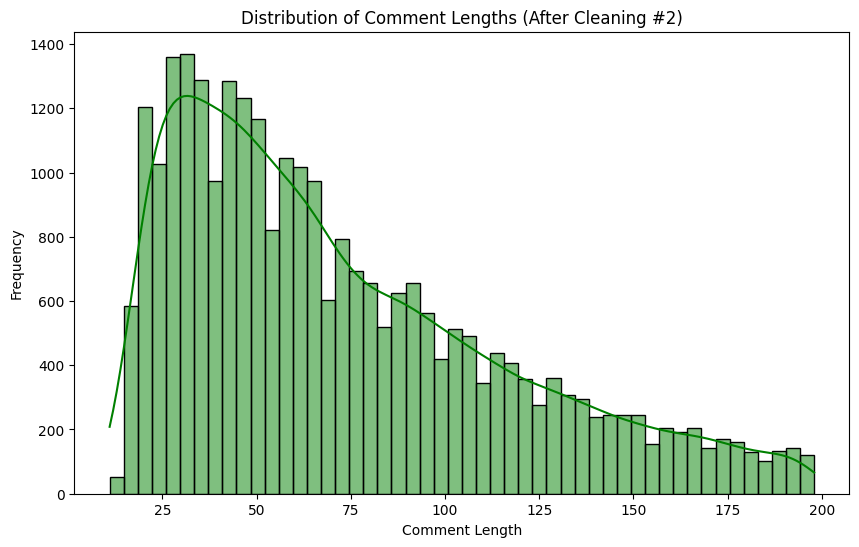

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(cleaned_df['comment_length'], bins=50, kde=True, color='green')
plt.title('Distribution of Comment Lengths (After Cleaning #2)')
plt.xlabel('Comment Length')
plt.ylabel('Frequency')
plt.show()

In [25]:
print(cleaned_df['label'].value_counts())

label
1    14197
0    13355
Name: count, dtype: int64


In [26]:
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

In [27]:
# خواندن دیتاست تمیز شده
cleaned_df = pd.read_csv("cleaned_data.csv")  # فرض بر این است که دیتاست تمیز شده در فایل موجود است

# تقسیم داده‌ها به سه مجموعه (آموزش 50%، اعتبارسنجی 20%، تست 30%)
train_data, temp_data = train_test_split(cleaned_df, test_size=0.5, stratify=cleaned_df['label'], random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.6, stratify=temp_data['label'], random_state=42)

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")

# ذخیره داده‌ها برای استفاده‌های بعدی
train_data.to_csv("snappfood_train.csv", index=False)
val_data.to_csv("snappfood_val.csv", index=False)
test_data.to_csv("snappfood_test.csv", index=False)

print("دیتاست آماده شد و ذخیره گردید.")

# لود کردن توکنایزر
tokenizer = AutoTokenizer.from_pretrained("HooshvareLab/bert-fa-base-uncased")  # تغییر دهید بر اساس مدل خودتان

# توکنایز کردن داده‌ها
train_encodings = tokenizer(list(train_data['comment']), truncation=True, padding=True, max_length=200)
val_encodings = tokenizer(list(val_data['comment']), truncation=True, padding=True, max_length=200)
test_encodings = tokenizer(list(test_data['comment']), truncation=True, padding=True, max_length=200)

# تبدیل برچسب‌ها به لیست
train_labels = list(train_data['label'])
val_labels = list(val_data['label'])
test_labels = list(test_data['label'])

print("توکنایز کردن داده‌ها با موفقیت انجام شد.")


Training samples: 13776
Validation samples: 5510
Test samples: 8266
دیتاست آماده شد و ذخیره گردید.


config.json:   0%|          | 0.00/440 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.20M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


توکنایز کردن داده‌ها با موفقیت انجام شد.


In [28]:
# بارگذاری داده‌های تقسیم‌شده
train_data = pd.read_csv("snappfood_train.csv")
val_data = pd.read_csv("snappfood_val.csv")
test_data = pd.read_csv("snappfood_test.csv")

In [29]:
# ذخیره داده‌های تقسیم‌شده
train_data.to_csv("snappfood_train.csv", index=False)
val_data.to_csv("snappfood_val.csv", index=False)
test_data.to_csv("snappfood_test.csv", index=False)

print("داده‌ها با موفقیت ذخیره شدند.")

داده‌ها با موفقیت ذخیره شدند.


In [30]:
!pip install transformers

In [31]:
from transformers import AutoModelForSequenceClassification
from torch.utils.data import DataLoader, Dataset
import torch
import pandas as pd

In [32]:
# بارگذاری مدل و توکنایزر ParsBERT
MODEL_NAME = "HooshvareLab/bert-fa-base-uncased-sentiment-snappfood"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# تعریف کلاس دیتاست برای PyTorch
class snappfoodDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = self.texts[index]
        label = self.labels[index]

        # توکنایز کردن متن
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }

tokenizer_config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/621 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.20M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/651M [00:00<?, ?B/s]

In [33]:
# تعریف دیتاست‌ها
train_dataset = snappfoodDataset(
    texts=train_data["comment"].tolist(),
    labels=train_data["label"].tolist(),
    tokenizer=tokenizer,
    max_len=200,
)

val_dataset = snappfoodDataset(
    texts=val_data["comment"].tolist(),
    labels=val_data["label"].tolist(),
    tokenizer=tokenizer,
    max_len=200,
)

test_dataset = snappfoodDataset(
    texts=test_data["comment"].tolist(),
    labels=test_data["label"].tolist(),
    tokenizer=tokenizer,
    max_len=200,
)

In [34]:
# تعریف DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("مدل و داده‌ها آماده شدند.")

مدل و داده‌ها آماده شدند.


In [35]:
# انتقال مدل به GPU در صورت وجود
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [36]:
import torch
import time
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm
import torch.nn as nn

In [37]:
pip install torchsummary


Note: you may need to restart the kernel to use updated packages.


In [38]:
# بارگذاری مدل از Hugging Face
MODEL_NAME = "HooshvareLab/bert-fa-base-uncased-sentiment-snappfood"
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

In [39]:
# افزودن Dropout و L2 Regularization
class CustomParsBERT(nn.Module):
    def __init__(self, model, dropout_prob=0.3, l2_lambda=0.01):
        super(CustomParsBERT, self).__init__()
        self.bert = model.bert
        self.dropout = nn.Dropout(p=dropout_prob)
        self.classifier = nn.Linear(model.config.hidden_size, model.config.num_labels)
        self.l2_lambda = l2_lambda

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = self.dropout(outputs.pooler_output)
        logits = self.classifier(pooled_output)

        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

            # افزودن L2 Regularization
            l2_reg = sum(param.norm(2) for param in self.classifier.parameters())
            loss += self.l2_lambda * l2_reg

            return loss, logits
        return logits

In [40]:
# تابع آموزش مدل
def train_model(learning_rate, batch_size):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CustomParsBERT(base_model)  # استفاده از base_model به جای base_model نامعتبر
    model.to(device)

    optimizer = AdamW(model.parameters(), lr=learning_rate)
    num_epochs = 3

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        train_preds, train_labels = [], []

        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}, LR={learning_rate}, BS={batch_size}"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            loss, logits = model(input_ids, attention_mask, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            train_preds.extend(preds)
            train_labels.extend(labels.cpu().numpy())

        # ارزیابی مدل روی داده اعتبارسنجی
        model.eval()
        val_loss = 0
        val_preds, val_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                loss, logits = model(input_ids, attention_mask, labels)
                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_labels.extend(labels.cpu().numpy())

        val_accuracy = accuracy_score(val_labels, val_preds)
        print(f"Epoch {epoch + 1}: Validation Accuracy: {val_accuracy:.4f}")

    return model, val_accuracy

# تنظیم هایپرپارامترها
learning_rates = [1e-5, 2e-5, 3e-5]
batch_sizes = [16, 32]

best_accuracy = 0
best_model = None
best_params = {}

for lr in learning_rates:
    for batch_size in batch_sizes:
        print(f"Training with lr={lr}, batch_size={batch_size}")
        model, val_accuracy = train_model(lr, batch_size)

        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            best_model = model
            best_params = {'learning_rate': lr, 'batch_size': batch_size}

print(f"Best Accuracy: {best_accuracy}")
print(f"Best Params: {best_params}")

# ذخیره مدل بهترین مدل
torch.save(best_model.state_dict(), 'best_model.pth')
print("Best model saved as 'best_model.pth'")

Training with lr=1e-05, batch_size=16


Epoch 1/3, LR=1e-05, BS=16: 100%|██████████| 431/431 [04:27<00:00,  1.61it/s]


Epoch 1: Validation Accuracy: 0.9336


Epoch 2/3, LR=1e-05, BS=16: 100%|██████████| 431/431 [04:27<00:00,  1.61it/s]


Epoch 2: Validation Accuracy: 0.9345


...

Epoch 3: Validation Accuracy: 0.8784
Training with lr=3e-05, batch_size=32


Epoch 1/3, LR=3e-05, BS=32: 100%|██████████| 431/431 [04:28<00:00,  1.60it/s]


Epoch 1: Validation Accuracy: 0.8873


Epoch 3/3, LR=3e-05, BS=32: 100%|██████████| 431/431 [04:28<00:00,  1.60it/s]


Epoch 3: Validation Accuracy: 0.8809
Best Accuracy: 0.9245009074410163
Best Params: {'learning_rate': 1e-05, 'batch_size': 16}
Best model saved as 'best_model.pth'


In [43]:
model.load_state_dict(torch.load('best_model.pth'))
model.to(device)

<ipython-input-43-1a0b334b2e30>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


CustomParsBERT(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(100000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwi

In [46]:
# فرض کنید که شما از دیتاست خود batch گرفته‌اید، اینجا یک مثال برای آن آورده شده است:
batch = next(iter(train_loader))  # این به طور موقت از train_loader استفاده می‌کند
input_ids = batch['input_ids'].to(device)
attention_mask = batch['attention_mask'].to(device)

# استفاده از مدل برای پیش‌بینی
logits = model(input_ids, attention_mask, labels=None)
preds = torch.argmax(logits, dim=1).cpu().numpy()

In [47]:
logits = model(input_ids, attention_mask, labels=None)
preds = torch.argmax(logits, dim=1).cpu().numpy()

In [53]:
def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating Model"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # دریافت logits از مدل
            outputs = model(input_ids, attention_mask)
            logits = model(input_ids, attention_mask)

            # محاسبه پیش‌بینی‌ها
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    # محاسبه معیارهای عملکرد
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    # نمایش نتایج
    print("Test Results:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print("\\nClassification Report:")
    print(classification_report(all_labels, all_preds, digits=4))

# بارگذاری مدل ذخیره‌شده
model.load_state_dict(torch.load('best_model.pth'))
model.to(device)

# ارزیابی مدل
evaluate_model(model, test_loader, device)


<ipython-input-53-719112a4d86d>:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))
Evaluating Model: 100%|██████████| 259/

Test Results:
  Accuracy: 0.8548
  Precision: 0.8582
  Recall: 0.8548
  F1-Score: 0.8542
\nClassification Report:
              precision    recall  f1-score   support

           0     0.8919    0.7971    0.8418      4006
           1     0.8265    0.9092    0.8659      4260

    accuracy                         0.8548      8266
   macro avg     0.8592    0.8531    0.8538      8266
weighted avg     0.8582    0.8548    0.8542      8266



Plotting ROC curve...


100%|██████████| 259/259 [00:50<00:00,  5.13it/s]


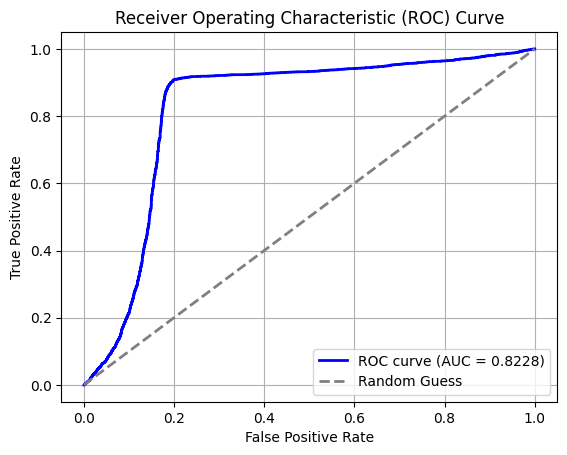

In [54]:
from sklearn.metrics import roc_curve, auc

# تابع ارزیابی برای محاسبه ROC
def evaluate_roc_curve(model, dataloader, device):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask, labels=None)  # فقط logits دریافت می‌شود
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()  # احتمال کلاس مثبت
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())

    # محاسبه FPR، TPR و AUC
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    # رسم منحنی ROC
    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

# ارزیابی مدل و رسم منحنی ROC
print("Plotting ROC curve...")
evaluate_roc_curve(model, test_loader, device)


In [58]:
# فرض بر این است که 'val_dataset' شامل داده‌های متنی است که به صورت لیست ذخیره شده‌اند
val_texts = val_dataset.texts  # یا روش مناسب دیگر برای دسترسی به داده‌های متنی
val_labels = val_dataset.labels  # یا روش مناسب دیگر برای دسترسی به برچسب‌ها

for batch in val_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    
    # دریافت logits از مدل
    logits = best_model(input_ids, attention_mask)

    # محاسبه پیش‌بینی‌ها
    val_predictions = logits.argmax(axis=1)

    # استخراج خطاها
    errors = [text for text, pred, label in zip(val_texts, val_predictions, val_labels) if pred != label]
    print("\nErrors:")
    print(errors)


Errors:
['سفارش من حدود دو ساعت بعد از ثبت رسید به دستم. بخاطر بارونی بودن هوا!! پیک اول خونه رو گم کرد و به جای زنجان رفت ستارخان. بعد از دو ساعت که رسید غذاها خیس و یخ بودن.', 'همه چی خوب ولی هات داگ دورش کلا سوخته بود و داخلش خام بود!!!!', 'یکی از سفارش\u200cها موز بود که به له و سیاه بودن حداقل اگه نمیتونین میوه سالم بفرستین از منو حذفش کنید لطفا رسیدگی کنید ک دیگه میوه له لورده برا کسی نفرستن!', 'تو لیست سفارش تخمه آفتابگردان بود که به جای آن بادام\u200cزمینی فرستاده بودند', 'سس الویه خیلی زیاد بود و لطفا توی منو بنویسید که با کالباس هست نه با مرغ', 'کیفیت غذا خوب بود ولی فاصله سیب تا دم در منزل کم هست نمیدونم چرا انقد غذا سرد بود، مشکل از رستوران بود یا اسنپ فود، ممنون', 'بجای یک عدد پنیر آنا، بدون سوال پنیر زیره!!!! فرستادند']

Errors:
['همیشه عالی و در کمترین زمان ممکن. ممنونم', 'مثله همیشه عالی، روزی شما پررونق', 'با سپاس تنوع کم بود', 'یکم موقع حمل قاطی شده بود.. ولی بارون میومدو داغ هم رسید پس ممنون', 'سلام. خداقوت تارت مخصوص گل گله خیلی خوشمزه و عالی بود. خیلی ممنون از مجم

In [59]:
# دیکشنری برای ذخیره‌سازی تعداد پیش‌بینی‌های اشتباه بر اساس کلاس‌ها
incorrect_predictions_by_class = {}

for batch in val_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    
    # دریافت logits از مدل
    logits = best_model(input_ids, attention_mask)

    # محاسبه پیش‌بینی‌ها
    val_predictions = logits.argmax(axis=1)

    # شمارش پیش‌بینی‌های اشتباه و گروه‌بندی بر اساس کلاس‌ها
    for pred, label in zip(val_predictions, val_labels):
        if pred != label:
            if label not in incorrect_predictions_by_class:
                incorrect_predictions_by_class[label] = 0
            incorrect_predictions_by_class[label] += 1  # افزایش شمارش پیش‌بینی‌های اشتباه برای هر کلاس

# چاپ تعداد پیش‌بینی‌های اشتباه بر اساس کلاس‌ها
for class_label, error_count in incorrect_predictions_by_class.items():
    print(f"Class {class_label} - Misclassified samples count: {error_count}")

Class 0 - Misclassified samples count: 1382
Class 1 - Misclassified samples count: 1379


### The number of misclassified data's from different classes is equal.

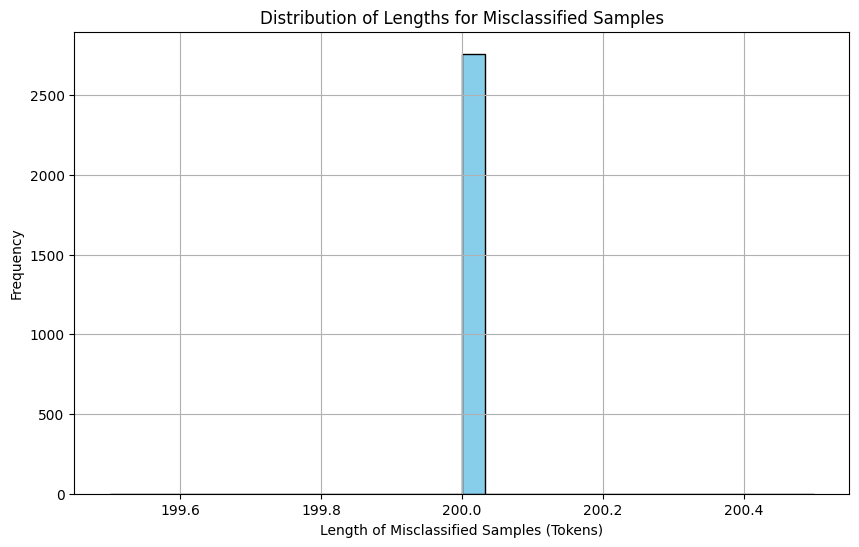

In [63]:
import matplotlib.pyplot as plt

# لیستی برای ذخیره طول داده‌های اشتباه
incorrect_lengths = []

for batch in val_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    
    # دریافت logits از مدل
    logits = best_model(input_ids, attention_mask)

    # محاسبه پیش‌بینی‌ها
    val_predictions = logits.argmax(axis=1)

    # شناسایی داده‌های اشتباه
    for pred, label, input_id in zip(val_predictions, val_labels, batch['input_ids']):
        if pred != label:
            # طول داده اشتباه را به لیست اضافه می‌کنیم
            incorrect_lengths.append(len(input_id))  # input_id شامل طول جمله است

# رسم هیستوگرام برای طول داده‌های اشتباه
plt.figure(figsize=(10, 6))
plt.hist(incorrect_lengths, bins=30, color='skyblue', edgecolor='black')  # تعداد سطل‌ها به 30 افزایش یافته
plt.title('Distribution of Lengths for Misclassified Samples')
plt.xlabel('Length of Misclassified Samples (Tokens)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
# ذخیره کردن وزن‌ها و وضعیت مدل
torch.save(model.state_dict(), 'model.pth')

In [ ]:
# ذخیره کردن مدل به همراه معماری
torch.save(model, 'full_model.pth')